In [64]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as metrics
from sklearn.metrics import brier_score_loss, roc_curve, auc, confusion_matrix, roc_auc_score, mean_squared_error
from sklearn.ensemble import RandomForestClassifier

# Set random seed
random_seed = 123



In [65]:
# define helper functions
def regression_results(y_true, y_pred):

    # Regression metrics
    explained_variance=metrics.explained_variance_score(y_true, y_pred)
    mean_absolute_error=metrics.mean_absolute_error(y_true, y_pred) 
    mse=metrics.mean_squared_error(y_true, y_pred) 
    median_absolute_error=metrics.median_absolute_error(y_true, y_pred)
    r2=metrics.r2_score(y_true, y_pred)

    print('explained_variance: ', round(explained_variance,4))    
    print('r2: ', round(r2,4))
    print('MAE: ', round(mean_absolute_error,4))
    print('MSE: ', round(mse,4))
    print('RMSE: ', round(np.sqrt(mse),4))
    
def create_coef_matrix(X, model):
    coef_matrix = pd.concat(
        [pd.DataFrame(X.columns),pd.DataFrame(model.coef_.flatten())], axis = 1
    )
    coef_matrix.columns = ['variable', 'coefficient']
    coef_matrix.iloc[-1] = ['Intercept', model.intercept_.flatten()[0]]
    return coef_matrix

def cv_summary(lambdas, C_values, model):
    d = {'lambdas': lambdas, 
         'C_values': C_values, 
         'mean_cv_score': model.scores_[1].mean(axis = 0)}
    return(pd.DataFrame(data=d))

"""def create_roc_plot(y_true, y_pred):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    all_coords = pd.DataFrame({
        'fpr': fpr,
        'tpr': tpr,
        'thresholds': thresholds
    })
    
    plot = ggplot(all_coords, aes(x = 'fpr', y = 'tpr')) \
        + geom_line(color=color[0], size = 0.7) \
        + geom_area(position = 'identity', fill = 'mediumaquamarine', alpha = 0.3) \
        + xlab("False Positive Rate (1-Specifity)") \
        + ylab("True Positive Rate (Sensitivity)") \
        + geom_abline(intercept = 0, slope = 1,  linetype = "dotted", color = "black") \
        + scale_y_continuous(limits = (0, 1), breaks = seq(0, 1, .1), expand = (0, 0.01)) \
        + scale_x_continuous(limits = (0, 1), breaks = seq(0, 1, .1), expand = (0.01, 0)) \
        + theme_bw()
    return(plot)
"""

def create_roc_plot(y_true, y_pred):
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Plot ROC curve line
    ax.plot(fpr, tpr, color='k', linewidth=0.7)
    
    # Fill area under curve
    ax.fill_between(fpr, tpr, alpha=0.3, color='white')
    
    # Add diagonal dotted line
    ax.plot([0, 1], [0, 1], linestyle=':', color='black')
    
    # Set axis labels
    ax.set_xlabel('False Positive Rate (1-Specificity)')
    ax.set_ylabel('True Positive Rate (Sensitivity)')
    
    # Set axis limits and ticks
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    
    # Style similar to theme_bw()
    ax.grid(True, linestyle='-', alpha=0.2)
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_color('black')
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, ax


def sigmoid_array(x):
    return(1 / (1 + np.exp(-x)))

def generate_fold_prediction(model, X, fold, param_index):
    fold_coef = model.coefs_paths_[1][fold,param_index,:]
    return(sigmoid_array(np.dot(X, np.transpose(fold_coef)[:-1]) +  np.transpose(fold_coef)[-1]))

"""def create_loss_plot(all_coords, optimal_threshold, curr_exp_loss):
    all_coords_copy = all_coords.copy()
    all_coords_copy['loss'] = (all_coords_copy.false_pos*FP + all_coords_copy.false_neg*FN)/all_coords_copy.n
    
    t = optimal_threshold
    l = curr_exp_loss
    
    plot = ggplot(all_coords_copy, aes(x = 'thresholds', y = 'loss')) + \
        geom_line(color=color[0], size=0.7) + \
        scale_x_continuous(breaks = seq(0, 1.1, by = 0.1)) + \
        coord_cartesian(xlim=(0,1))+ \
        geom_vline(xintercept = t , color = color[0] ) + \
        annotate(geom = "text", x = t - 0.01, y= max(all_coords_copy.loss) - 0.4,
                 label="best threshold: " + str(round(t,2)),
                 colour=color[1], angle=90, size = 7) +\
        annotate(geom = "text", x = t + 0.06, y= l,\
                 label= str(round(l, 2)), size = 7) +\
        theme_bw()
    return(plot)"""

def create_loss_plot(all_coords, optimal_threshold, curr_exp_loss):
    # Create copy and calculate loss
    all_coords_copy = all_coords.copy()
    all_coords_copy['loss'] = (all_coords_copy.false_pos*FP + all_coords_copy.false_neg*FN)/all_coords_copy.n
    
    t = optimal_threshold
    l = curr_exp_loss

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(6, 5))

    # Plot loss line
    ax.plot(all_coords_copy['thresholds'], all_coords_copy['loss'], 
            color= 'k', linewidth=0.7)

    # Add vertical line at optimal threshold
    ax.axvline(x=t, color = 'k')

    # Add annotations
    ax.text(t - 0.04, max(all_coords_copy.loss) - 0.5,
            f"best threshold: {t:.2f}", 
            color = 'k', 
            rotation=90, 
            fontsize = 9)
    
    ax.text(t + 0.06, l,
            f"{l:.2f}",
            fontsize = 9)

    # Set x-axis ticks and limits
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_xlim(0, 1)

    # Style similar to theme_bw()
    ax.grid(True, linestyle='-', alpha=0.2)
    ax.set_facecolor('white')
    ax.set_xlabel('threshold')
    ax.set_ylabel('loss')
    for spine in ax.spines.values():
        spine.set_color('black')

    # Adjust layout
    plt.tight_layout()

    return fig, ax



"""def create_roc_plot_with_optimal(all_coords, optimal_threshold):
    all_coords_copy = all_coords.copy()
    all_coords_copy['sp'] = all_coords_copy.true_neg/all_coords_copy.neg
    all_coords_copy['se'] = all_coords_copy.true_pos/all_coords_copy.pos
    
    best_coords = all_coords_copy[all_coords_copy.thresholds == optimal_threshold]
    sp = best_coords.sp.values[0]
    se = best_coords.se.values[0]

    plot = ggplot(all_coords_copy, aes(x = 'sp', y = 'se')) +\
        geom_line(color=color[0], size=0.7) +\
        scale_y_continuous(breaks = seq(0, 1.1, by = 0.1)) +\
        scale_x_reverse(breaks = seq(0, 1.1, by = 0.1)) +\
        geom_point(data = pd.DataFrame({'sp': [sp], 'se': [se]})) +\
        annotate(geom = "text", x = sp, y = se + 0.03,
                 label = str(round(sp, 2)) + ', ' + str(round(se, 2)), size = 7) +\
        theme_bw()
    return(plot)
"""
def create_roc_plot_with_optimal(all_coords, optimal_threshold):
    # Create copy and calculate metrics
    all_coords_copy = all_coords.copy()
    all_coords_copy['sp'] = all_coords_copy.true_neg/all_coords_copy.neg
    all_coords_copy['se'] = all_coords_copy.true_pos/all_coords_copy.pos
    
    # Get optimal point
    best_coords = all_coords_copy[all_coords_copy.thresholds == optimal_threshold]
    sp = best_coords.sp.values[0]
    se = best_coords.se.values[0]
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Plot ROC curve
    ax.plot(all_coords_copy['sp'], all_coords_copy['se'],
            color='k', linewidth=0.9)
    
    # Add optimal point
    ax.scatter([sp], [se], color='k', s = 100)
    
    # Add text annotation
    ax.text(sp, se + 0.03,
            f"{sp:.2f}, {se:.2f}",
            fontsize = 9,
            ha='center')
    ax.text(sp - 0.02, se - 0.18,
            'specificity (TNR) \n& sensitivity (TPR) \nat the best threshold',
            fontsize = 9,
            ha='center'
           )
    
    # Set axis ticks and limits
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_xlabel('specificity')
    ax.set_ylabel('sensitivity')
    
    # Reverse x-axis
    ax.set_xlim(1, 0)
    
    # Style similar to theme_bw()
    ax.grid(True, linestyle='-', alpha=0.2)
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_color('black')
    
    # Adjust layout
    plt.tight_layout()
    plt.show()
    return fig, ax

## 1. Introduction & Data

In this analysis we ...
Dataset filters - Existing firms in 2012, 2014


In [2]:
# Load the cleaned dataset
data = pd.read_csv('./data_clean/bisnode_firms_clean.csv')

print(f"Dataset shape: {data.shape}")
print(f"\nColumns: {list(data.columns[:20])}...")
print(f"\nYears in data: {sorted(data['year'].unique())}")

Dataset shape: (38547, 114)

Columns: ['year', 'comp_id', 'begin', 'end', 'amort', 'curr_assets', 'curr_liab', 'extra_exp', 'extra_inc', 'extra_profit_loss', 'fixed_assets', 'inc_bef_tax', 'intang_assets', 'inventories', 'liq_assets', 'material_exp', 'personnel_exp', 'profit_loss_year', 'sales', 'share_eq']...

Years in data: [2012, 2014]


In [141]:
# check the dataset
data.describe()

,year,comp_id,amort,curr_assets,curr_liab,extra_exp,extra_inc,extra_profit_loss,fixed_assets,inc_bef_tax,...,profit_loss_year_pl_quad,share_eq_bs_quad,ceo_age,flag_low_ceo_age,flag_high_ceo_age,flag_miss_ceo_age,ceo_young,labor_avg_mod,flag_miss_labor_avg,sales_mil_log_sq
count,38547.0%,38547.0%,38547.0%,38547.0%,38547.0%,38547.0%,38547.0%,38547.0%,38547.0%,38547.0%,...,38547.0%,38547.0%,38547.0%,38547.0%,38547.0%,38547.0%,38547.0%,38547.0%,38547.0%,38547.0%
mean,2013.0%,153308590938.1%,9497.2%,109689.9%,90819.1%,576.6%,2083.9%,1496.5%,155384.0%,9085.6%,...,0.1%,0.5%,47.1%,0.0%,0.0%,0.1%,0.3%,0.6%,0.2%,11.7%
std,1.0%,137789576868.2%,48142.8%,753246.0%,522870.5%,12811.3%,68671.8%,68928.5%,1432875.7%,160505.8%,...,0.3%,0.4%,10.7%,0.1%,0.1%,0.3%,0.4%,1.4%,0.4%,10.2%
min,2012.0%,1001541.0%,-14896.3%,0.0%,-8759.3%,-8496.3%,-6988.9%,-1569122.2%,0.0%,-14870437.0%,...,0.0%,0.0%,25.0%,0.0%,0.0%,0.0%,0.0%,0.1%,0.0%,0.0%
25%,2012.0%,28875507712.0%,166.7%,3744.4%,3851.9%,0.0%,0.0%,0.0%,420.4%,-5292.6%,...,0.0%,0.1%,39.0%,0.0%,0.0%,0.0%,0.0%,0.1%,0.0%,3.7%
50%,2014.0%,114594816000.0%,1000.0%,12788.9%,15422.2%,0.0%,0.0%,0.0%,5340.7%,514.8%,...,0.0%,0.4%,47.1%,0.0%,0.0%,0.0%,0.0%,0.3%,0.0%,9.2%
75%,2014.0%,256639729664.0%,4363.0%,44338.9%,50696.3%,0.0%,0.0%,0.0%,44011.1%,5703.7%,...,0.1%,1.0%,54.0%,0.0%,0.0%,0.0%,1.0%,0.6%,0.0%,16.8%
max,2014.0%,464105013248.0%,3570863.0%,88087072.0%,51289128.0%,1913111.1%,11978744.0%,11978744.0%,159444496.0%,7670470.5%,...,1.0%,1.0%,75.0%,1.0%,1.0%,1.0%,1.0%,46.4%,1.0%,47.7%


## 2. Data wrangling

In [3]:
# Base dataset
data_base = data[data['year'] == 2012]
data_base['sales_2012'] = data_base['sales']
print(f"2012 baseline observations: {len(data_base)}")

# Join dataset for target
data_join = data[data['year'] == 2014][['comp_id', 'sales']]
data_join['sales_2014'] = data_join['sales']
data_join = data_join.drop('sales', axis=1)
print(f"2014 observations: {len(data_join)}")

# Inner join on comp_id
data_merged = pd.merge(data_base, data_join, on='comp_id', how='inner')  
print(f"Joined dataset observations: {len(data_merged)}")

2012 baseline observations: 19036
2014 observations: 19511
Joined dataset observations: 14603


### 2.1. Label engineering

- CAGR formula was used to calculate the annual growth rates
- According to OECD above 20% fast growing + data is not imbalanced (30-70%)

In [4]:
# Calculate CAGR
data_merged['growth_rate'] = ((data_merged['sales_2014'] / data_merged['sales_2012']) ** (1/2)) - 1

In [5]:
# Check missings
missing_summary = data_merged[['sales_2012', 'sales_2014', 'growth_rate']].isnull().sum()
print("\nMissing values in the target and components:\n", missing_summary)


Missing values in the target and components:
 sales_2012     0
sales_2014     0
growth_rate    0
dtype: int64


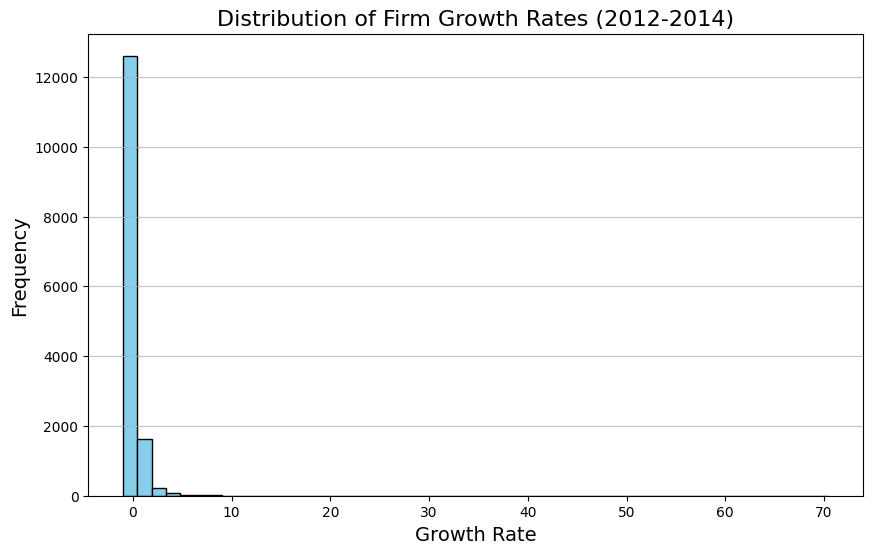

In [6]:
# Histogram of growth rates
plt.figure(figsize=(10, 6))
plt.hist(data_merged['growth_rate'], bins=50, color='skyblue', edgecolor='black') 
plt.title('Distribution of Firm Growth Rates (2012-2014)', fontsize=16)
plt.xlabel('Growth Rate', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.show()

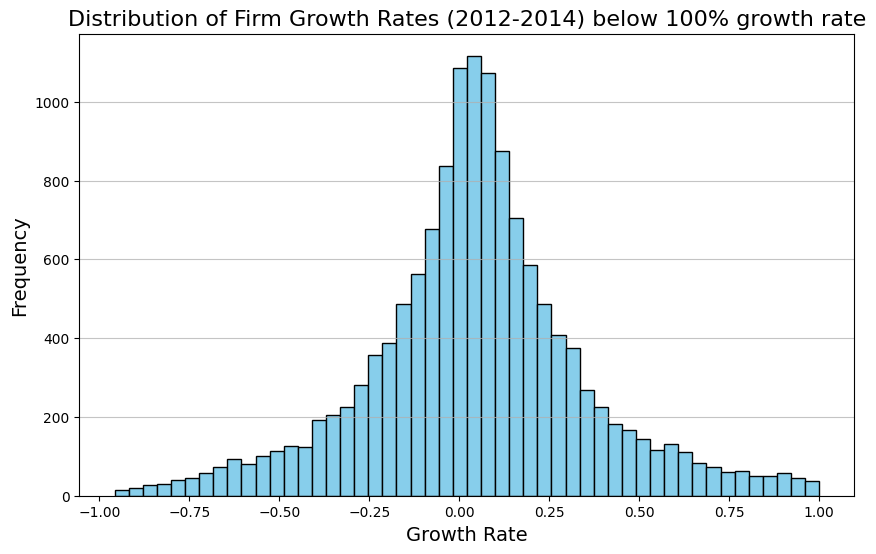

In [7]:
# Histogram of growth rates below 100% to check distribution of more typical growth rates
plt.figure(figsize=(10, 6))
plt.hist(data_merged[data_merged['growth_rate'] < 1]['growth_rate'], bins=50, color='skyblue', edgecolor='black') 
plt.title('Distribution of Firm Growth Rates (2012-2014) below 100% growth rate', fontsize=16)
plt.xlabel('Growth Rate', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.show()

In [8]:
# Check extremes
print("\nNumber of companies above 100% growth rate:", len(data_merged[data_merged['growth_rate'] > 1]))
print("\nNumber of companies above 500% growth rate:", len(data_merged[data_merged['growth_rate'] > 5]))
print("\nNumber of companies above 1000% growth rate:", len(data_merged[data_merged['growth_rate'] > 10]))



Number of companies above 100% growth rate: 872

Number of companies above 500% growth rate: 80

Number of companies above 1000% growth rate: 15


In [9]:
# Check sample distribution across growth rate thresholds
cutoffs = list(np.arange(0.05, 0.5, 0.05))

results = []
for threshold in cutoffs:
    # Count observations
    count_below = len(data_merged[data_merged['growth_rate'] < threshold])
    count_above = len(data_merged[data_merged['growth_rate'] >= threshold])
    total = count_below + count_above
    
    # Calculate percentages
    pct_below = (count_below / total) * 100
    pct_above = (count_above / total) * 100
    
    # Store in list
    results.append({
        'Cutoff': threshold,
        'Count Below': count_below,
        '% Below': pct_below,
        'Count Above': count_above,
        '% Above': pct_above
    })

cumulative_table = pd.DataFrame(results)
cumulative_table['Cutoff'] = cumulative_table['Cutoff'].apply(lambda x: f"{x:.0%}")
pd.options.display.float_format = '{:.1f}%'.format
cumulative_table

,Cutoff,Count Below,% Below,Count Above,% Above
0,5%,7082,48.5%,7521,51.5%
1,10%,8444,57.8%,6159,42.2%
2,15%,9525,65.2%,5078,34.8%
3,20%,10348,70.9%,4255,29.1%
4,25%,11011,75.4%,3592,24.6%
5,30%,11537,79.0%,3066,21.0%
6,35%,11972,82.0%,2631,18.0%
7,40%,12286,84.1%,2317,15.9%
8,45%,12537,85.9%,2066,14.1%


In [10]:
# Create target
fast_growth_threshold = 0.2  
data_merged['fast_growing'] = (data_merged['growth_rate'] >= fast_growth_threshold).astype(int)

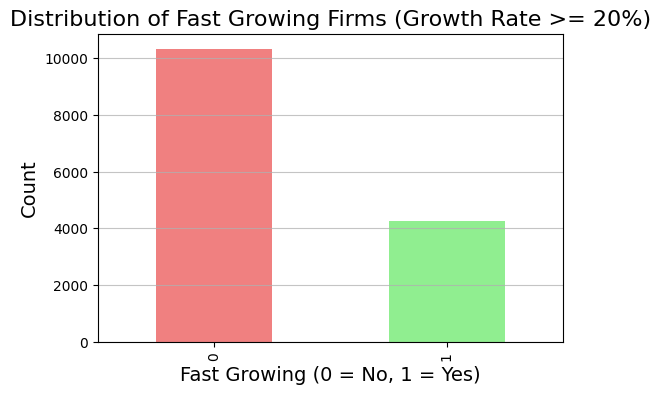

In [11]:
# create a bar chart of the distribution of the target variable
plt.figure(figsize=(6, 4))
data_merged['fast_growing'].value_counts().plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.title('Distribution of Fast Growing Firms (Growth Rate >= 20%)', fontsize=16)
plt.xlabel('Fast Growing (0 = No, 1 = Yes)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.show()

### 2.2. Feature engineering

In [12]:
# Categorize industries (10-33: Manufacturing, 55-56: Accommodation and Food Service Activities)

data_merged['manufacturing_flg'] = np.where(
    (data_merged['ind2'] >= 10) & (data_merged['ind2'] <= 33), 1, 0)
data_merged['services_flg'] = np.where( 
    (data_merged['ind2'] >= 55) & (data_merged['ind2'] <= 56), 1, 0)
data_merged.groupby(['manufacturing_flg', 'services_flg'])['comp_id'].count().reset_index(name='count')

,manufacturing_flg,services_flg,count
0,0,1,9809
1,1,0,4794


In [13]:
# Create interactions
interactions = [
    'ind2_cat*age', 'ind2_cat*age2',
    'ind2_cat*sales_mil_log', 'ind2_cat*ceo_age', 'ind2_cat*foreign_management',
    'ind2_cat*female', 'ind2_cat*urban_m', 'ind2_cat*labor_avg_mod',
    'sales_mil_log*age', 'sales_mil_log*female', 'sales_mil_log*profit_loss_year_pl',
    'sales_mil_log*foreign_management'
]

for col_name in interactions:
    var1, var2 = col_name.split('*')
    data_merged[col_name] = data_merged[var1] * data_merged[var2]

In [14]:
# Create feature categories

# raw financial variables
rawvars = ["curr_assets", "curr_liab", "extra_exp", "extra_inc", "extra_profit_loss", "fixed_assets",
              "inc_bef_tax", "intang_assets", "inventories", "liq_assets", "material_exp", "personnel_exp",
              "profit_loss_year", "sales", "share_eq", "subscribed_cap"]

# quality vars - financials
qualityvars = ["balsheet_flag", "balsheet_length", "balsheet_notfullyear"]

# financial ratios
engvar = ["total_assets_bs", "fixed_assets_bs", "liq_assets_bs", "curr_assets_bs",
            "share_eq_bs", "subscribed_cap_bs", "intang_assets_bs", "extra_exp_pl",
            "extra_inc_pl", "extra_profit_loss_pl", "inc_bef_tax_pl", "inventories_pl",
            "material_exp_pl", "profit_loss_year_pl", "personnel_exp_pl"]

# squared financial items
engvar2 = ["extra_profit_loss_pl_quad", "inc_bef_tax_pl_quad",
             "profit_loss_year_pl_quad", "share_eq_bs_quad"]

# data quality flags - financial ratios
engvar3 = []
for col in data_merged.columns:
    if col.endswith('flag_low') or col.endswith('flag_high') or col.endswith('flag_error') or col.endswith('flag_zero'):
        engvar3.append(col)

# human capital related variables
hr = ["female", "ceo_age", "flag_high_ceo_age", "flag_low_ceo_age",
        "flag_miss_ceo_age", "ceo_count", "labor_avg_mod",
        "flag_miss_labor_avg", "foreign_management"]

# firms related variables
firm = ["age", "age2", "ind2_cat", "manufacturing_flg", "services_flg",
        #"m_region_loc", 
        "urban_m"]

# interactions for logit, LASSO
interactions1 = ["ind2_cat*age", "ind2_cat*age2",
                   "ind2_cat*sales_mil_log",
                   "ind2_cat*ceo_age", "ind2_cat*foreign_management",
                   "ind2_cat*female",   "ind2_cat*urban_m", "ind2_cat*labor_avg_mod"]

# more interactions
interactions2 = ["sales_mil_log*age", "sales_mil_log*female",
                "sales_mil_log*profit_loss_year_pl", "sales_mil_log*foreign_management"]

# keep only the variables we need for modeling
model_vars = rawvars + qualityvars + engvar + engvar2 + engvar3 + hr + firm + interactions1 + interactions2 + ['comp_id', 'growth_rate', 'fast_growing']
data_model = data_merged[model_vars]
data_model.shape
data_model.head()



,curr_assets,curr_liab,extra_exp,extra_inc,extra_profit_loss,fixed_assets,inc_bef_tax,intang_assets,inventories,liq_assets,...,ind2_cat*female,ind2_cat*urban_m,ind2_cat*labor_avg_mod,sales_mil_log*age,sales_mil_log*female,sales_mil_log*profit_loss_year_pl,sales_mil_log*foreign_management,comp_id,growth_rate,fast_growing
0,9629.6%,1303.7%,0.0%,0.0%,0.0%,190566.7%,-7696.3%,0.0%,0.0%,9048.1%,...,0.0%,168.0%,36.4%,-26.9%,-0.0%,6.7%,-0.0%,1001541.0%,1.0%,1
1,203885.2%,120444.5%,0.0%,0.0%,0.0%,23459.3%,11818.5%,0.0%,677.8%,15077.8%,...,0.0%,81.0%,12.4%,0.8%,0.0%,0.0%,0.0%,1002029.0%,-0.6%,0
2,160166.7%,18911.1%,0.0%,0.0%,0.0%,933574.1%,96751.9%,1537.0%,11866.7%,131766.7%,...,0.0%,110.0%,89.2%,-16.7%,-0.0%,-0.2%,-0.0%,1011889.0%,0.0%,0
3,199903.7%,8274.1%,0.0%,7.4%,7.4%,118229.6%,-1429.6%,0.0%,0.0%,18585.2%,...,0.0%,110.0%,39.3%,-22.5%,-0.0%,0.0%,-0.0%,1014183.0%,-0.1%,0
4,1811.1%,592.6%,0.0%,11.1%,11.1%,52155.6%,-1096.3%,118.5%,496.3%,1314.8%,...,28.0%,112.0%,8.6%,-40.0%,-2.5%,0.8%,-0.0%,1018301.0%,0.2%,0


## 3. Explanatory data analysis

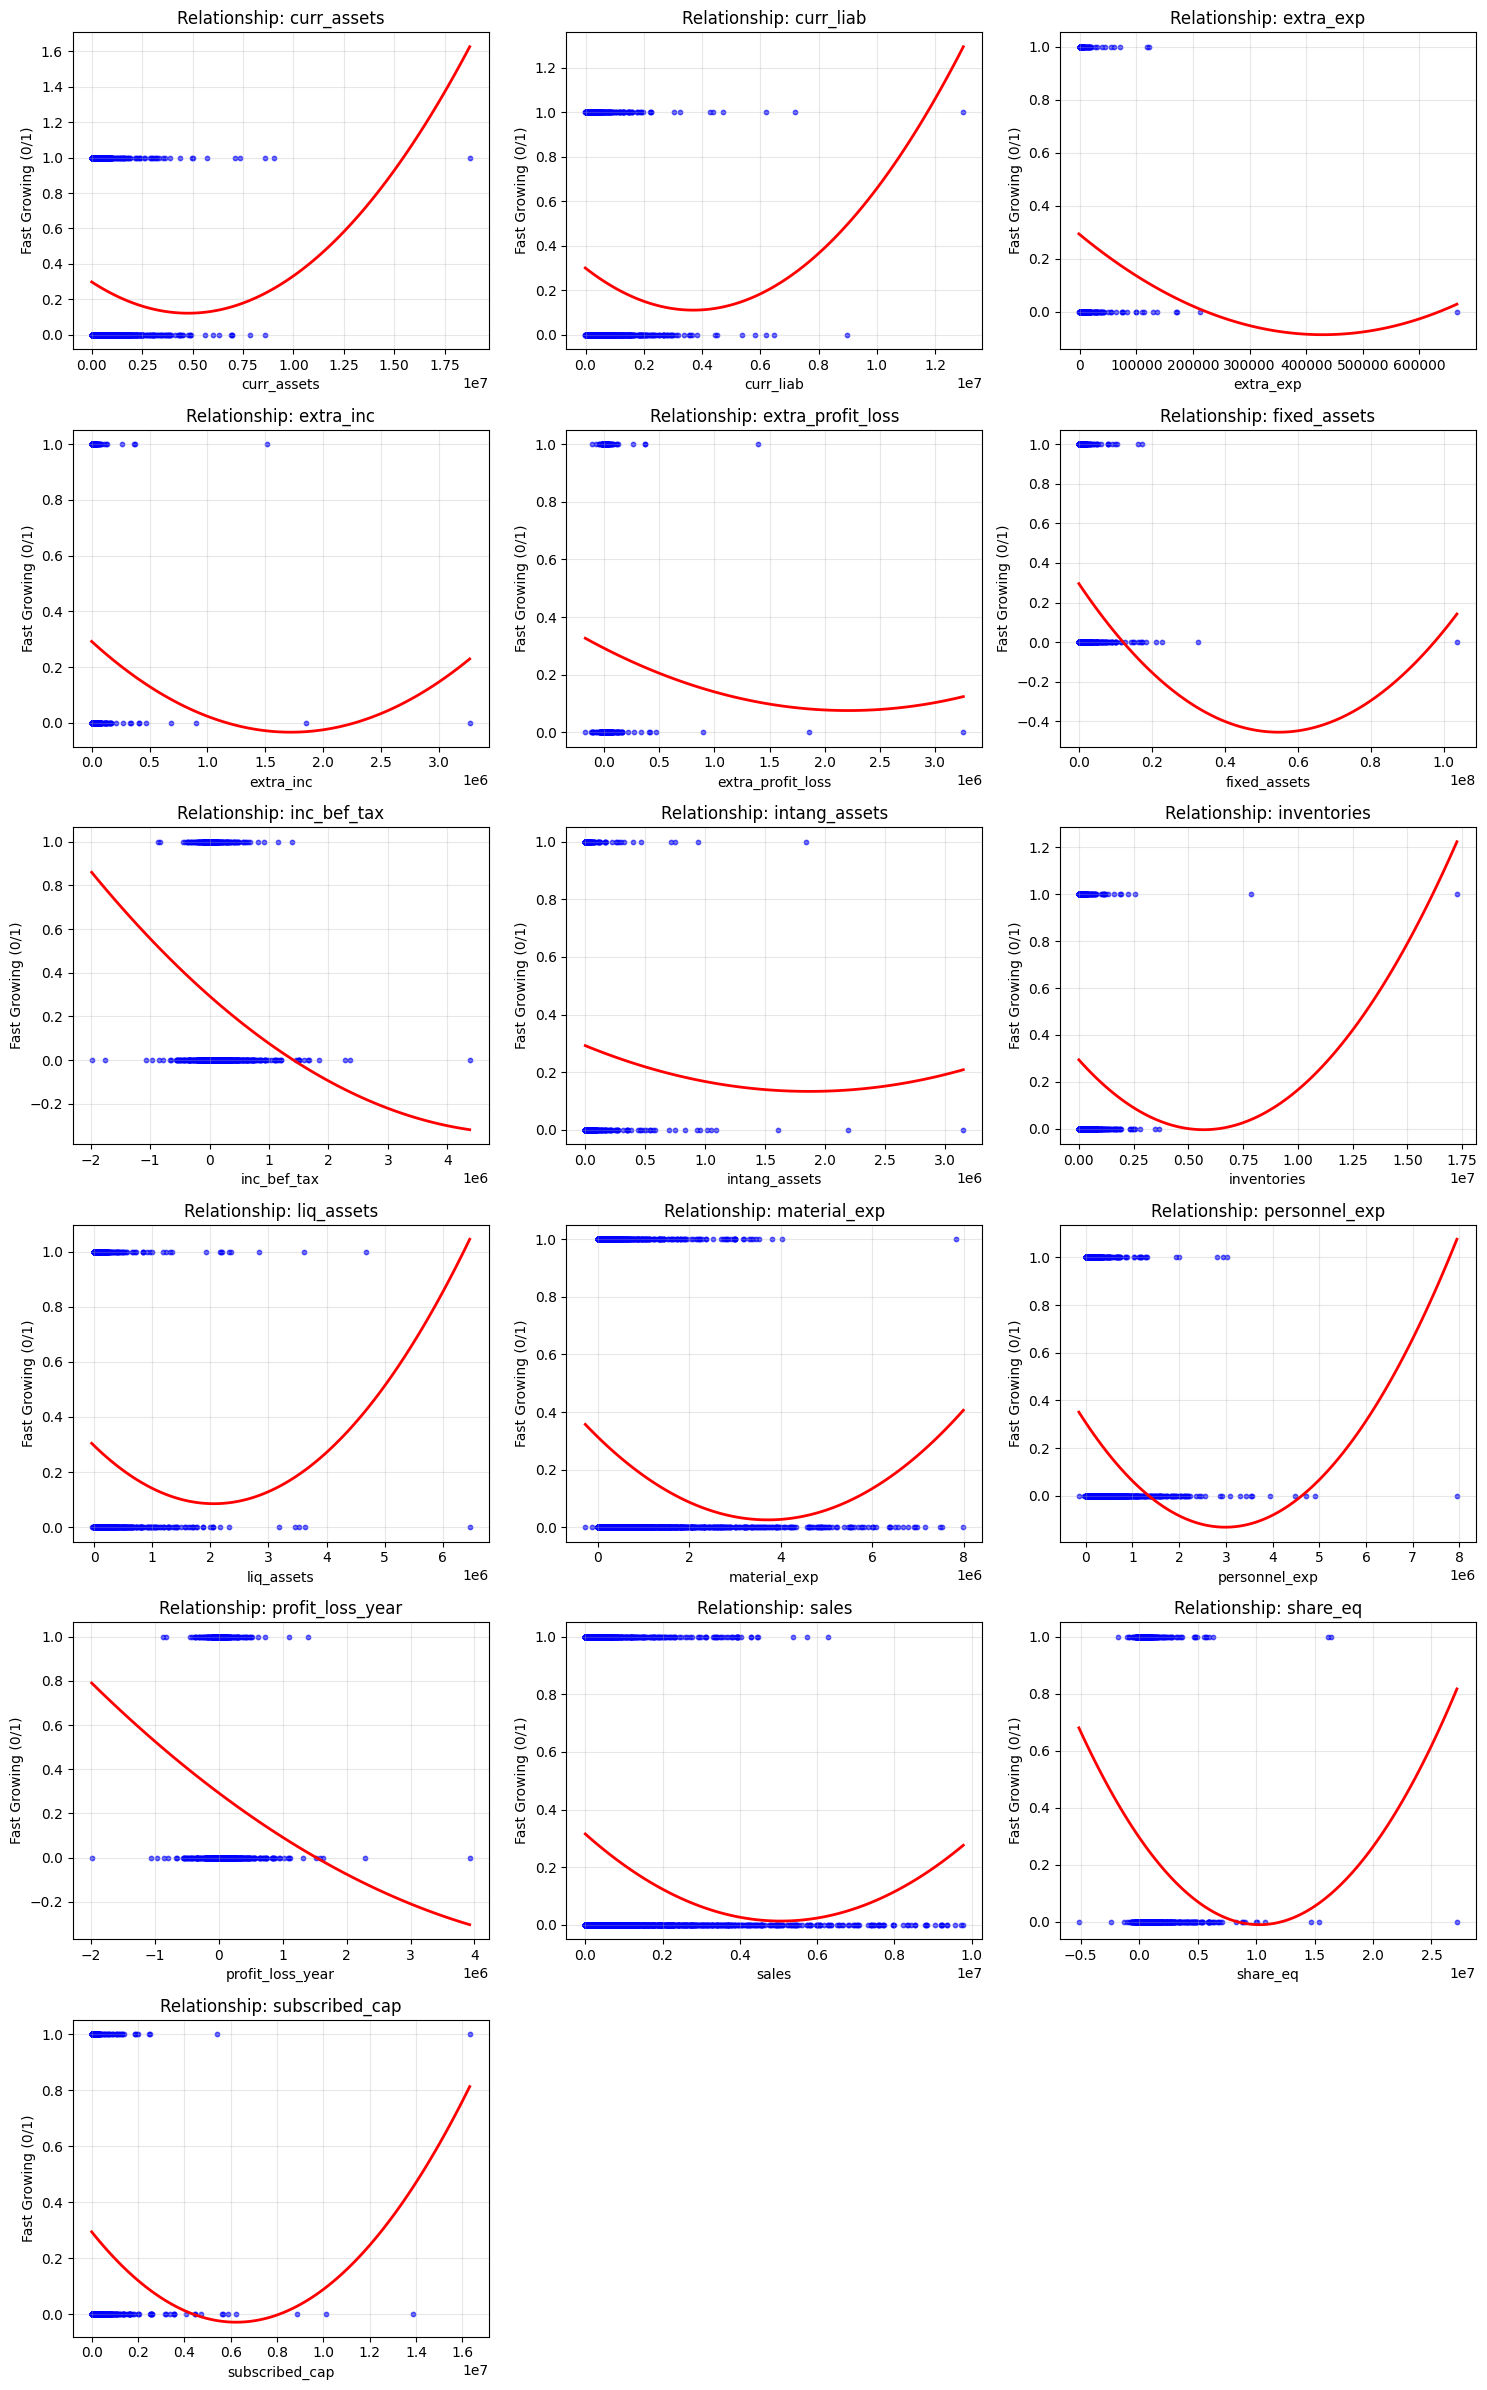

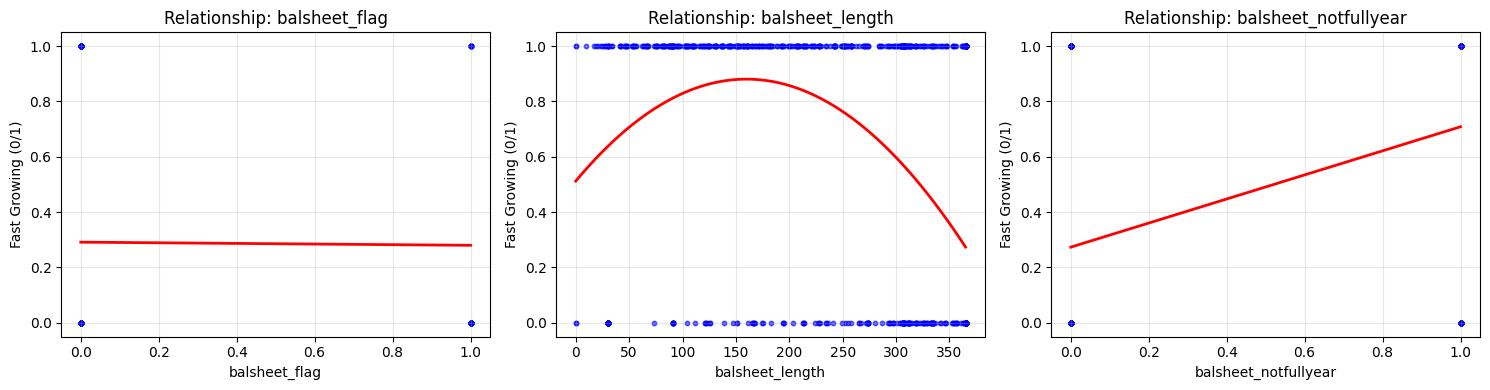

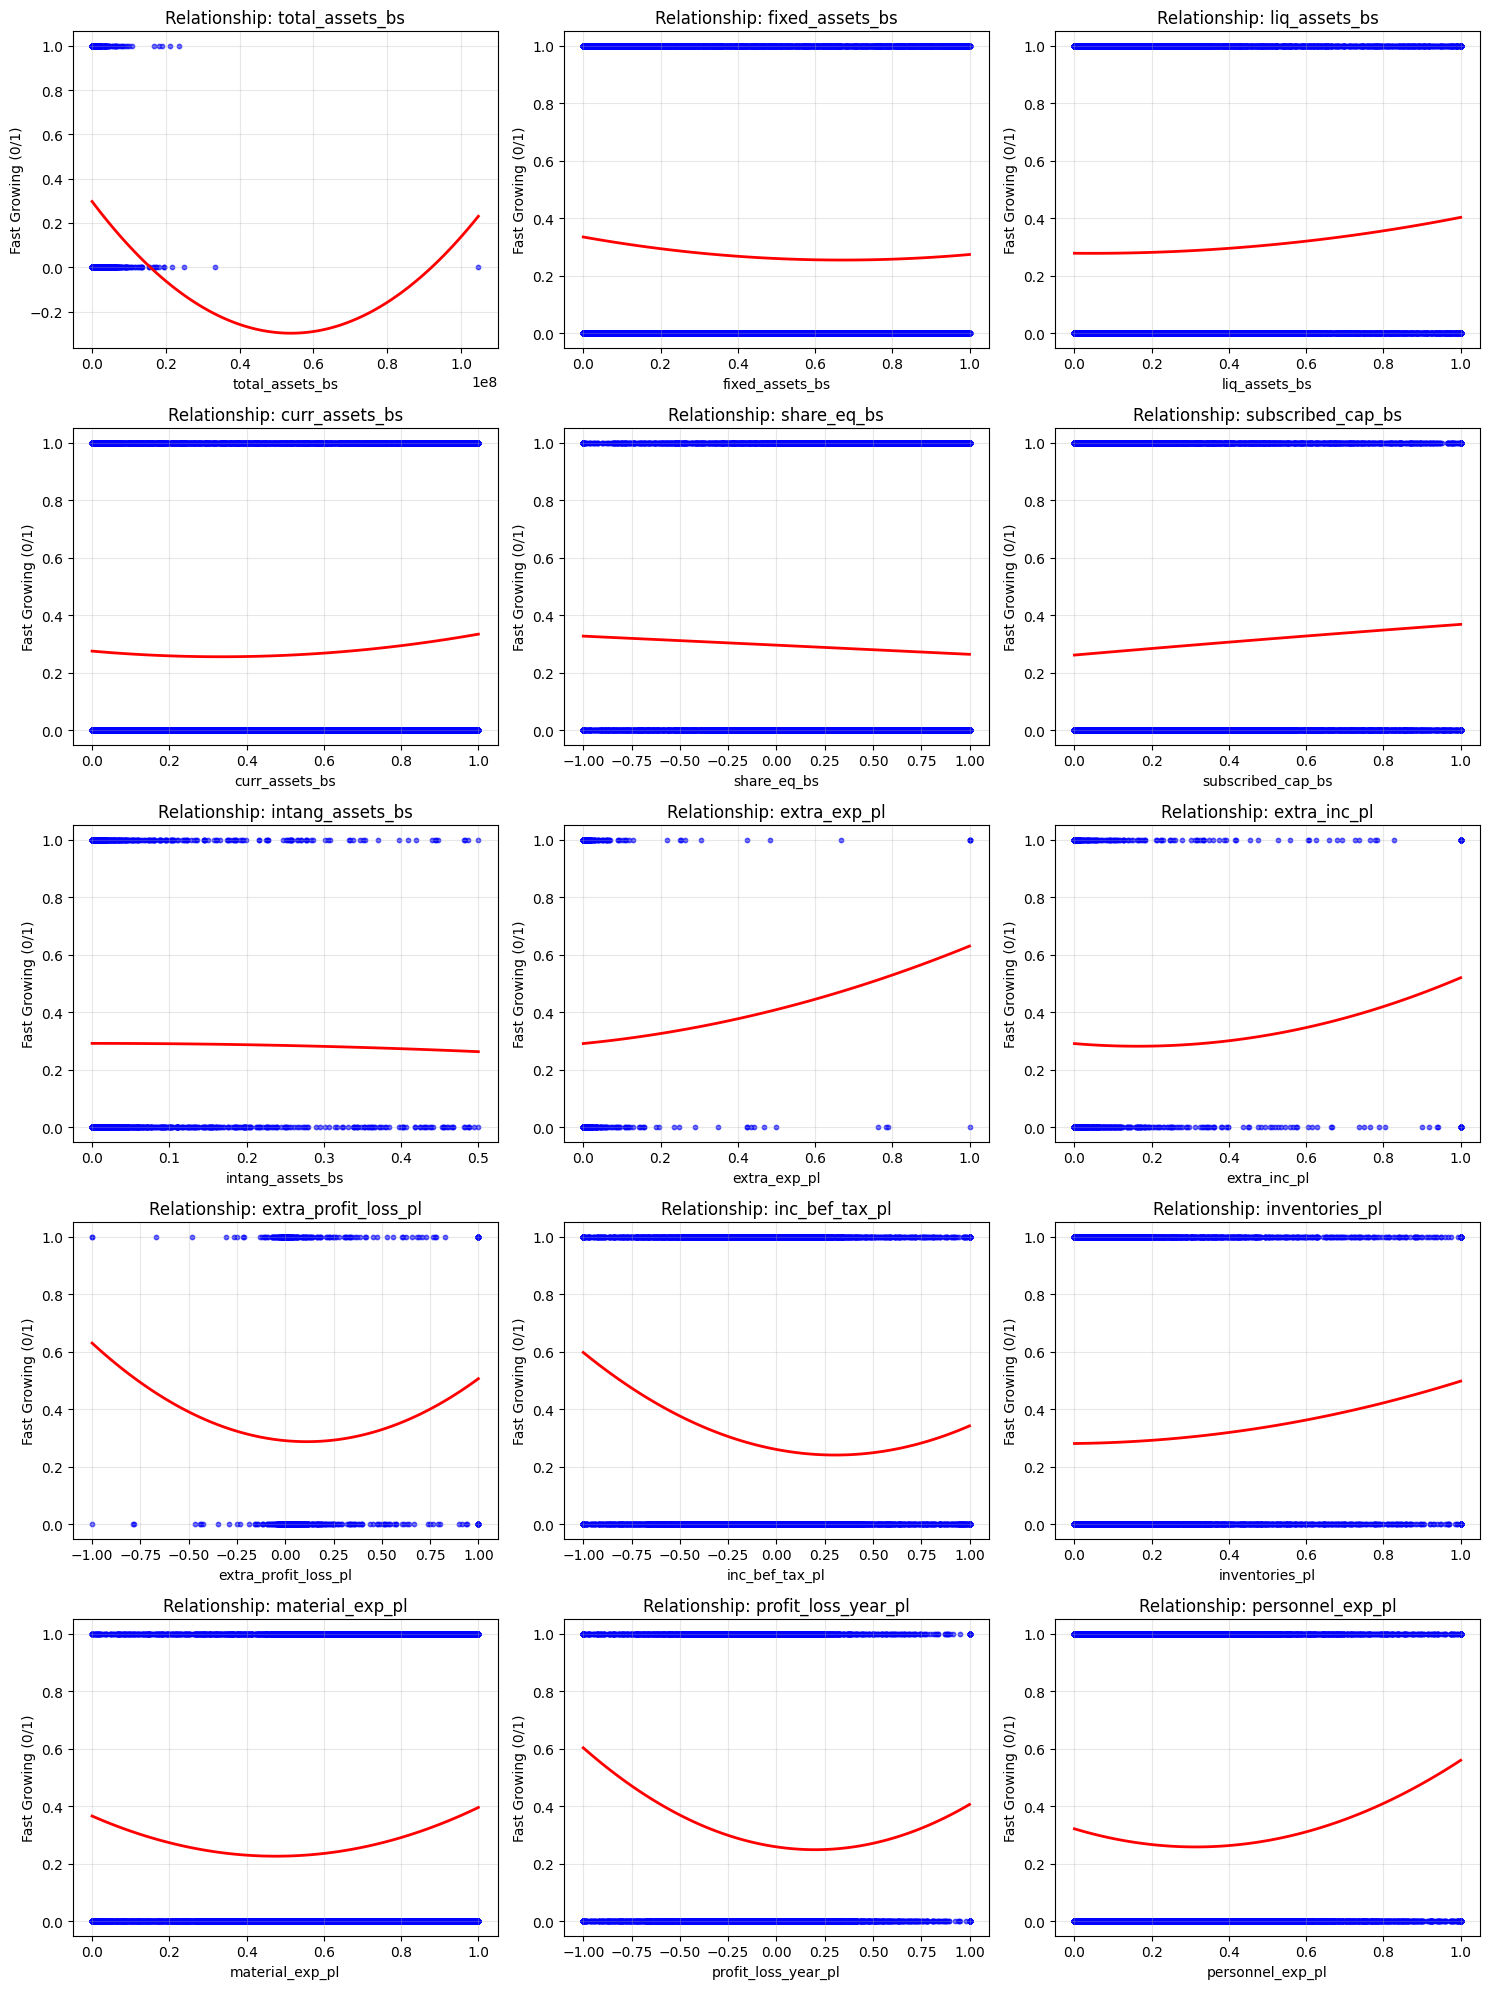

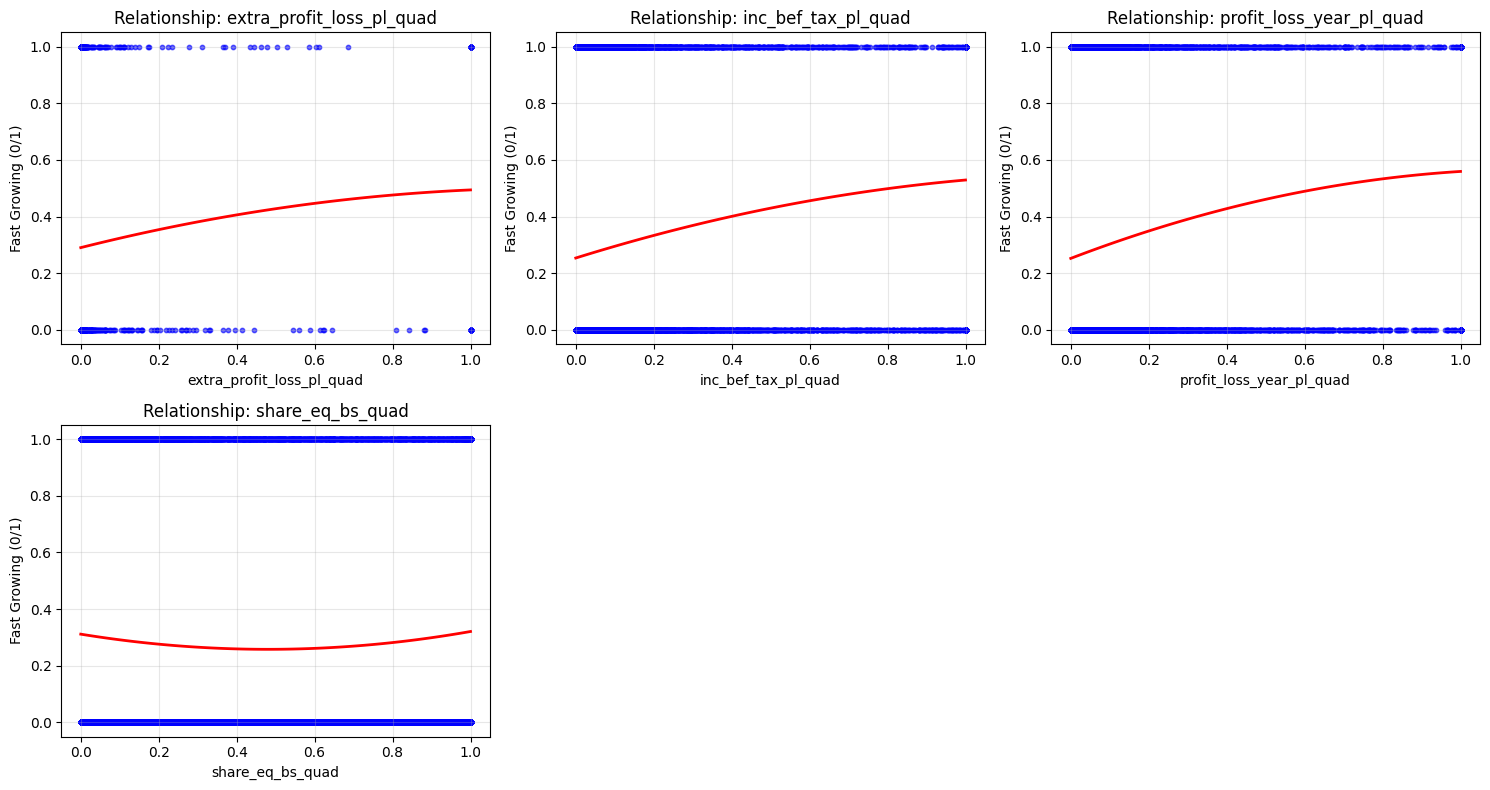

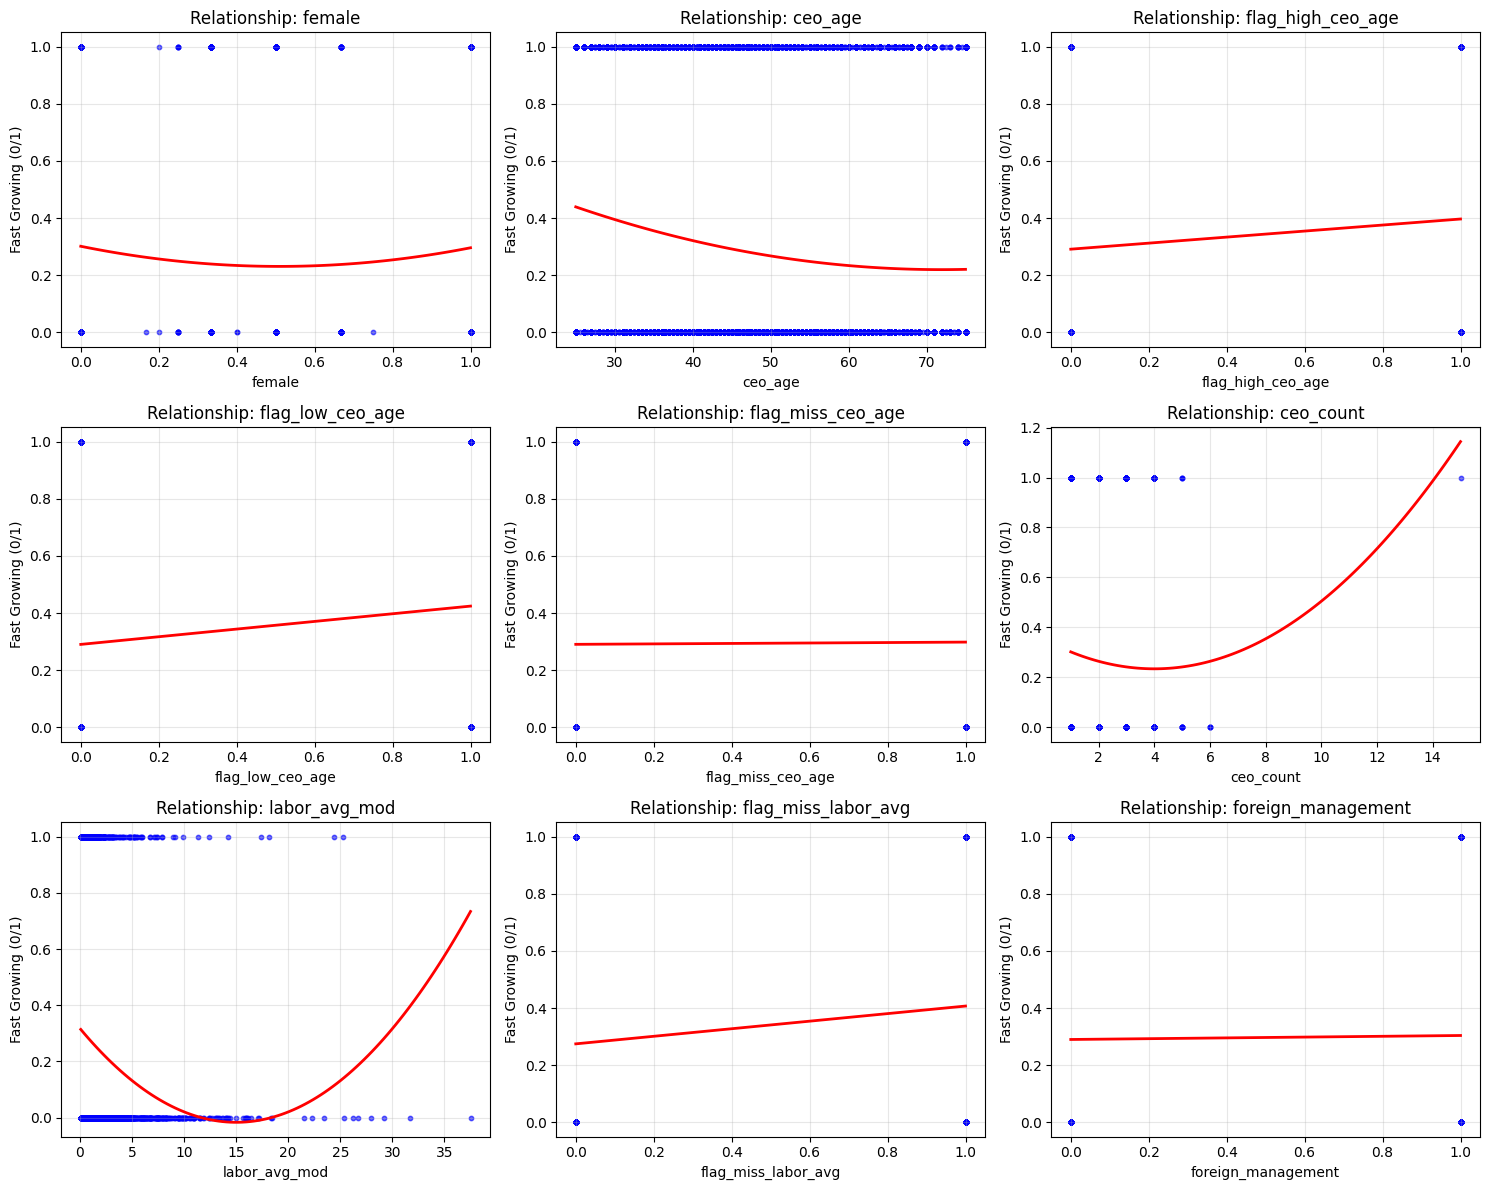

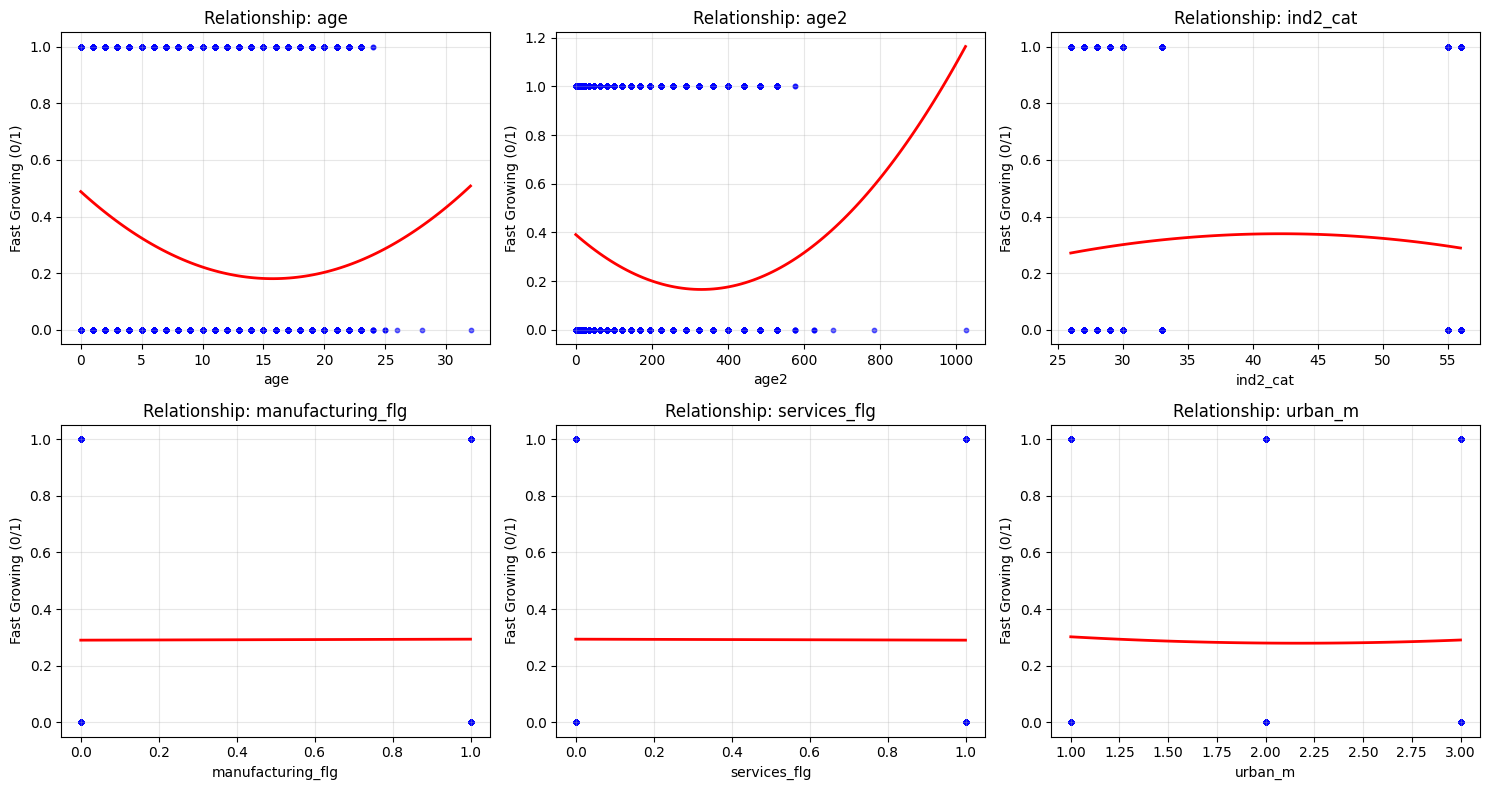

In [17]:
# Create function to visualize the relationship

def plot_relationship(predictor_list):
    cols_to_plot = ['fast_growing'] + predictor_list
    data_m = data_model[cols_to_plot].copy()

    # 2. Determine grid size (equivalent to plot_grid with ncol=3)
    num_plots = len(predictor_list)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # 3. Create the figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4 * num_rows))
    axes = axes.flatten()  # Flatten 2D grid to 1D for easy looping

    # 4. Loop through variables and plot
    for i, var in enumerate(predictor_list):
        if data_m[var].nunique() < 3: # if binary or has very few levels, force a straight line, else curve
            current_order = 1
        else:
            current_order = 2
        sns.regplot(
            data=data_m,
            x=var,                  # The raw variable (x-axis)
            y='fast_growing',   # The target (y-axis)
            order=current_order,                # Polynomial degree 2 (matches poly(x,2))
            ci=None,                # Remove confidence interval shading (matches se=F)
            scatter_kws={'s': 10, 'alpha': 0.6, 'color': 'blue'}, # Point style
            line_kws={'color': 'red', 'linewidth': 2},            # Line style
            ax=axes[i]
        )
        
        # Labels and Titles
        axes[i].set_xlabel(var)
        axes[i].set_ylabel('Fast Growing (0/1)')
        axes[i].set_title(f'Relationship: {var}')
        axes[i].grid(True, alpha=0.3) # match theme_bw() mostly

    # 5. Clean up empty subplots (if any)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_relationship(rawvars)
plot_relationship(qualityvars)
plot_relationship(engvar)
plot_relationship(engvar2)
plot_relationship(hr)
plot_relationship(firm)


## 4. Modeling

In [24]:
# Split data into training and holdout sets
index_train, index_holdout= train_test_split(
    data_model.index.values, train_size=round(0.8*len(data_model.index)), random_state = random_seed)

y = data_model['fast_growing']
y_train = y.iloc[index_train]
y_holdout = y.iloc[index_holdout]

11682 2921
2921 11682


### 4.1. Logit

In [47]:
# Define logistic regression variables and variable matrices
logit_1_vars = rawvars
logit_2_vars = rawvars + qualityvars
logit_3_vars = rawvars + qualityvars + engvar + engvar2 + engvar3
logit_4_vars = rawvars + qualityvars + engvar + engvar2 + engvar3 + hr + firm + interactions1 + interactions2

logit_X1 = data_model[logit_1_vars]
logit_X2 = data_model[logit_2_vars]
logit_X3 = data_model[logit_3_vars]
logit_X4 = data_model[logit_4_vars]

In [30]:
# configure cross-validation
k = KFold(n_splits = 5, shuffle = True, random_state = random_seed)

# no regularisation needed so setting the paremeter to very high value
Cs_value_logit = [1e20]

In [ ]:
# Define logit models
logit_model_vars = [logit_X1.iloc[index_train], logit_X2.iloc[index_train], logit_X3.iloc[index_train]]

In [166]:
# Set placeholder for model results
logit_models = dict()
CV_RMSE_folds = dict()
CV_AUC_folds = dict()    


In [167]:
# build logistic regression models with cross-validation, save CV RMSE and AUC for each fold

for i in range(len(logit_model_vars)):
    
    print(f'Running logit regression {i+1}...')

    # Optimize for RMSE (Brier score) in cross-validation
    LRCV_brier = LogisticRegressionCV(
        Cs = Cs_value_logit, 
        cv = k,
        refit = True, 
        scoring = 'neg_brier_score', 
        solver = "newton-cg", 
        tol=1e-7, 
        random_state = random_seed)
    
    # Optimize for AUC in cross-validation
    LRCV_auc = LogisticRegressionCV(
        Cs=Cs_value_logit,
        cv=k,
        refit=True,
        scoring="roc_auc",
        solver="newton-cg",
        tol=1e-7,
        random_state=random_seed
    )
    
    # Save model
    model_name = 'logit_X'+str(i+1)
    logit_models[model_name] = LRCV_brier.fit(logit_model_vars[i], y_train)
    
    # Calculate RMSE on test for each fold
    CV_RMSE_folds['logit_X'+str(i+1)] = np.sqrt(-1*(logit_models['logit_X'+str(i+1)].scores_[1])).flatten()

    # Calculate AUC on test for each fold
    # logit_models["logit_X" + str(i + 1)] = LRCV_auc.fit(logit_model_vars[i], y_train)
    CV_AUC_folds["logit_X" + str(i + 1)] = LRCV_auc.fit(logit_model_vars[i], y_train).scores_[1].ravel()


Running logit regression 1...
Running logit regression 2...
Running logit regression 3...


In [168]:
# CV RMSE for each fold by model
pd.DataFrame(CV_RMSE_folds)

,logit_X1,logit_X2,logit_X3
0,0.4%,0.4%,0.4%
1,0.5%,0.4%,0.4%
2,0.4%,0.4%,0.4%
3,0.5%,0.4%,0.4%
4,0.4%,0.4%,0.4%


In [169]:
# CV AUC for each fold by model
pd.DataFrame(CV_AUC_folds)

,logit_X1,logit_X2,logit_X3
0,0.6%,0.6%,0.6%
1,0.6%,0.6%,0.6%
2,0.6%,0.6%,0.7%
3,0.6%,0.7%,0.7%
4,0.6%,0.6%,0.6%


In [170]:
# Create summary table
model_fits = pd.DataFrame(logit_models, index=["Model fit"]).T

summary = (
    model_fits["Model fit"]
    .apply(lambda x: x.n_features_in_)
    .to_frame(name="Number of Coefficients")
)

summary["CV RMSE"] = pd.DataFrame(CV_RMSE_folds).T.mean(axis=1)
summary["CV AUC"] = pd.DataFrame(CV_AUC_folds).T.mean(axis=1)

summary

,Number of Coefficients,CV RMSE,CV AUC
logit_X1,16,0.5%,0.6%
logit_X2,19,0.4%,0.6%
logit_X3,66,0.4%,0.6%


### 4.2. Logit with LASSO

In [171]:
# standardize variables for LASSO
standardized_logitvars = pd.DataFrame(StandardScaler().fit_transform(logit_X4.iloc[index_train]))
standardized_logitvars.columns = logit_X4.columns

In [ ]:
# configure LASSO with cross-validation to find optimal lambda
lambdas=list(10**np.arange(-1,-4.01, -1/3))
n_obs = standardized_logitvars.shape[0]*4/5
Cs_values = [1/(l*n_obs) for l in lambdas]


In [174]:
# build LASSO logistic regression model with cross-validation (based on Brier score)
logLasso = LogisticRegressionCV(
    Cs = Cs_values, 
    penalty = 'l1',
    cv = k, 
    refit = True, 
    scoring = 'neg_brier_score', 
    solver = 'liblinear',
    random_state = random_seed)

# Save model
logit_models["logit_LASSO"] = logLasso.fit(standardized_logitvars, y_train)

In [179]:
# Show lambda values and corresponding mean CV RMSE
cv_summary_lasso = cv_summary(lambdas, Cs_values, logit_models["logit_LASSO"])
cv_summary_lasso["mean_cv_RMSE"] = np.sqrt(cv_summary_lasso["mean_cv_score"] * -1)
cv_summary_lasso

,lambdas,C_values,mean_cv_score,mean_cv_RMSE
0,0.1%,0.0%,-0.2%,0.5%
1,0.0%,0.0%,-0.2%,0.4%
2,0.0%,0.0%,-0.2%,0.4%
3,0.0%,0.0%,-0.2%,0.4%
4,0.0%,0.0%,-0.2%,0.4%
5,0.0%,0.0%,-0.2%,0.4%
6,0.0%,0.1%,-0.2%,0.4%
7,0.0%,0.2%,-0.2%,0.4%
8,0.0%,0.5%,-0.2%,0.4%
9,0.0%,1.1%,-0.2%,0.4%


In [186]:
# Best lambda
best_lambda_index = cv_summary_lasso["mean_cv_RMSE"].idxmin()
best_lambda = cv_summary_lasso.sort_values('mean_cv_RMSE', ascending = True).iloc[0,0]
best_lambda

0.001000000000000001

In [ ]:
# Get the RMSE by folds
for i, l in enumerate(lambdas):
    if l == best_lambda:
        best_lambda_i = i
        # CV_RMSE_folds['logit_LASSO'] = np.sqrt(-1*(logLasso_brier_fitted.scores_[1][:,i])).tolist()
        CV_RMSE_folds['logit_LASSO'] = np.sqrt(-1*(logit_models['logit_LASSO'].scores_[1][:,i])).tolist()



,logit_X1,logit_X2,logit_X3,logit_LASSO
0,0.4%,0.4%,0.4%,0.4%
1,0.5%,0.4%,0.4%,0.4%
2,0.4%,0.4%,0.4%,0.4%
3,0.5%,0.4%,0.4%,0.4%
4,0.4%,0.4%,0.4%,0.4%


In [193]:
# Calculate fold AUC for LASSO
logLasso_auc = LogisticRegressionCV(
    Cs=Cs_values,
    penalty="l1",
    cv=k,
    refit=True,
    scoring="roc_auc",
    solver="liblinear",
    random_state=random_seed,
)
logLasso_auc_fitted = logLasso_auc.fit(standardized_logitvars, y_train)

CV_AUC_folds["logit_LASSO"] = logLasso_auc_fitted.scores_[1][
    :, best_lambda_index
]

In [190]:
# CV RMSE for each fold by model
pd.DataFrame(CV_RMSE_folds)

,logit_X1,logit_X2,logit_X3,logit_LASSO
0,0.4%,0.4%,0.4%,0.4%
1,0.5%,0.4%,0.4%,0.4%
2,0.4%,0.4%,0.4%,0.4%
3,0.5%,0.4%,0.4%,0.4%
4,0.4%,0.4%,0.4%,0.4%


In [191]:
# CV AUC for each fold by model
pd.DataFrame(CV_AUC_folds)

,logit_X1,logit_X2,logit_X3,LASSO
0,0.6%,0.6%,0.6%,0.7%
1,0.6%,0.6%,0.6%,0.7%
2,0.6%,0.6%,0.7%,0.7%
3,0.6%,0.7%,0.7%,0.7%
4,0.6%,0.6%,0.6%,0.7%


In [198]:
# Create summary table
model_fits = pd.DataFrame(logit_models, index=["Model fit"]).T

summary = (
    model_fits["Model fit"]
    .apply(lambda x: x.n_features_in_)
    .to_frame(name="Number of Coefficients (with intercept)")
)

summary.loc["logit_LASSO", "Number of Coefficients (with intercept)"] = len(
    [i for i in model_fits.loc["logit_LASSO"].values[0].coef_[0] if i != 0]
)

summary["CV RMSE"] = pd.DataFrame(CV_RMSE_folds).T.mean(axis=1)
summary["CV AUC"] = pd.DataFrame(CV_AUC_folds).T.mean(axis=1)

summary

,Number of Coefficients (with intercept),CV RMSE,CV AUC
logit_X1,16,0.5%,0.6%
logit_X2,19,0.4%,0.6%
logit_X3,66,0.4%,0.6%
logit_LASSO,67,0.4%,0.7%


In [199]:
# Coefficient matrix (non-zero coefficients only) for LASSO model
coef_matrix = create_coef_matrix(standardized_logitvars, logit_models["logit_LASSO"])
coef_nonzero = coef_matrix[coef_matrix['coefficient'].abs() > 0].copy()
coef_nonzero['abs_coef'] = coef_nonzero['coefficient'].abs()
coef_nonzero = coef_nonzero.sort_values(by='abs_coef', ascending=False).drop(columns=['abs_coef'])
coef_nonzero

,variable,coefficient
92,Intercept,-1.0%
81,ind2_cat*age,-0.6%
83,ind2_cat*sales_mil_log,-0.6%
82,ind2_cat*age2,0.3%
0,curr_assets,0.2%
...,...,...
40,inventories_pl_flag_high,0.0%
14,share_eq,0.0%
9,liq_assets,0.0%
28,extra_profit_loss_pl,0.0%


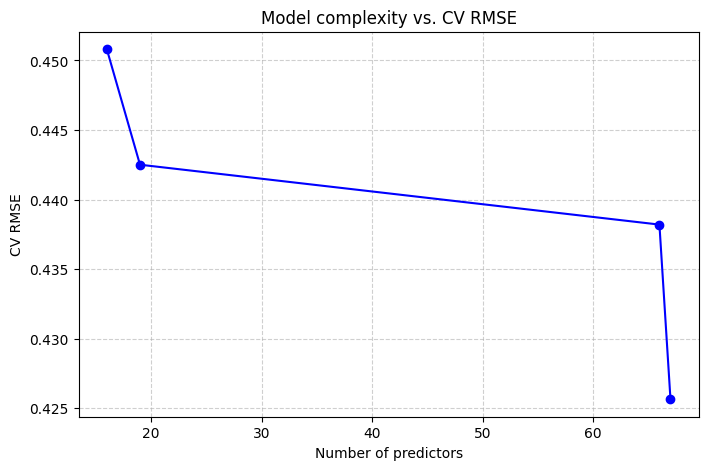

In [201]:
# Summary of logit models with CV RMSE
plt.figure(figsize=(8, 5))
plt.plot(summary['Number of Coefficients (with intercept)'], summary['CV RMSE'], marker='o', linestyle='-', color='b')
plt.title('Model complexity vs. CV RMSE')
plt.xlabel('Number of predictors')
plt.ylabel('CV RMSE')
plt.grid(True, linestyle='--', alpha=0.6)

### 4.3. Random Forest

## 5. Loss function

## 6. Summary